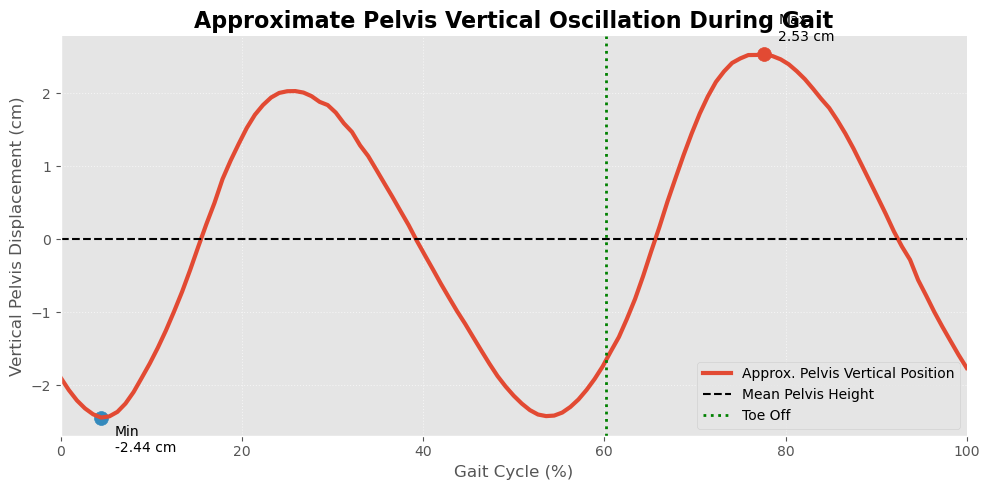

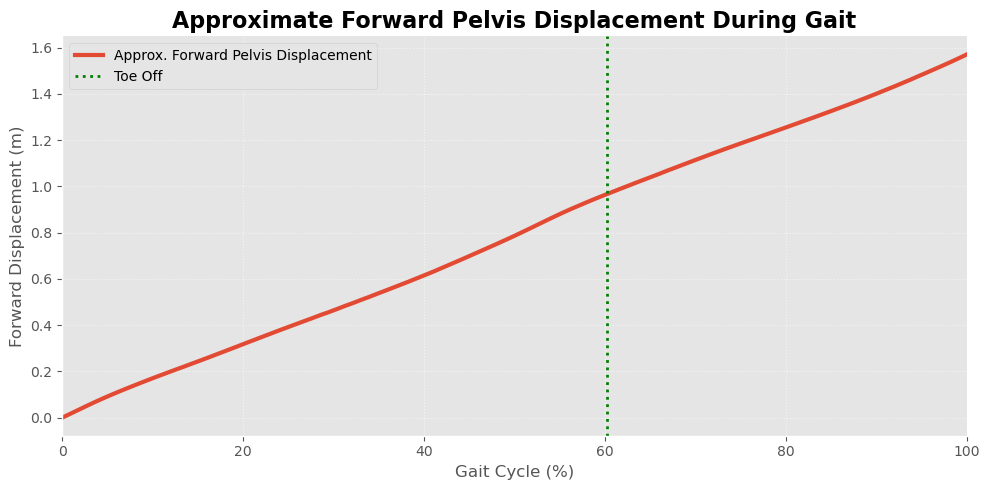

========== Gait Timing ==========
Gait cycle time: 1.13 s
Stance time: 0.68 s
Swing time: 0.45 s
Stance phase: 60.2%
Swing phase: 39.8%
Toe-off: 60.2% gait cycle
Cadence: 106.2 steps/min

========== Pelvis Vertical Oscillation ==========
Vertical pelvis excursion: 4.98 cm

========== Forward Walking Speed ==========
Forward displacement: 1.57 m
Walking speed: 1.39 m/s
Walking speed: 5.00 km/h


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Events

events = {
    "LHS_start": 3.35,
    "LHS_end": 4.48,
    "LTO": 4.03,
}

# Read TRC Excel File

df = pd.read_excel("Walk_002_markers.TRC.xlsx", header=None)

# Rows 82:195 correspond to 3.35 s to 4.48 s

rows = slice(82, 195)

# Extract Time

time_gait = pd.to_numeric(
    df.iloc[rows, 1],
    errors="coerce"
).reset_index(drop=True)

# Extract Pelvis Marker Coordinates

# X = mediolateral
# Y = vertical
# Z = forward progression


# Vertical coordinates = Y columns
LASI_y = pd.to_numeric(df.iloc[rows, 3], errors="coerce").reset_index(drop=True)
RASI_y = pd.to_numeric(df.iloc[rows, 6], errors="coerce").reset_index(drop=True)
LPSI_y = pd.to_numeric(df.iloc[rows, 9], errors="coerce").reset_index(drop=True)
RPSI_y = pd.to_numeric(df.iloc[rows, 12], errors="coerce").reset_index(drop=True)

# Forward coordinates = Z columns
LASI_z = pd.to_numeric(df.iloc[rows, 4], errors="coerce").reset_index(drop=True)
RASI_z = pd.to_numeric(df.iloc[rows, 7], errors="coerce").reset_index(drop=True)
LPSI_z = pd.to_numeric(df.iloc[rows, 10], errors="coerce").reset_index(drop=True)
RPSI_z = pd.to_numeric(df.iloc[rows, 13], errors="coerce").reset_index(drop=True)

# Approximate Pelvis Centre

pelvis_vertical_mm = (LASI_y + RASI_y + LPSI_y + RPSI_y) / 4
pelvis_forward_mm = (LASI_z + RASI_z + LPSI_z + RPSI_z) / 4

pelvis_vertical_cm = pelvis_vertical_mm / 10
pelvis_forward_m = pelvis_forward_mm / 1000

# Time Normalisation

time_norm = (
    (time_gait - time_gait.iloc[0]) /
    (time_gait.iloc[-1] - time_gait.iloc[0])
) * 100

# Relative Displacements

pelvis_vertical_relative_cm = (
    pelvis_vertical_cm - pelvis_vertical_cm.mean()
)

pelvis_forward_relative_m = (
    pelvis_forward_m - pelvis_forward_m.iloc[0]
)

# Toe-Off Position

toe_off = (
    (events["LTO"] - events["LHS_start"]) /
    (events["LHS_end"] - events["LHS_start"])
) * 100

# Gait Timing Metrics

gait_cycle_time = events["LHS_end"] - events["LHS_start"]
stance_time = events["LTO"] - events["LHS_start"]
swing_time = events["LHS_end"] - events["LTO"]

stance_percent = (stance_time / gait_cycle_time) * 100
swing_percent = (swing_time / gait_cycle_time) * 100

cadence = (60 / gait_cycle_time) * 2

# Pelvis Oscillation Metrics

vertical_excursion_cm = (
    pelvis_vertical_cm.max() -
    pelvis_vertical_cm.min()
)

vertical_max_idx = pelvis_vertical_relative_cm.idxmax()
vertical_min_idx = pelvis_vertical_relative_cm.idxmin()

# Forward Speed Metrics

forward_displacement_m = (
    pelvis_forward_m.iloc[-1] -
    pelvis_forward_m.iloc[0]
)

walking_speed_m_s = forward_displacement_m / gait_cycle_time
walking_speed_km_h = walking_speed_m_s * 3.6

# Plot 1: Vertical Pelvis Oscillation

plt.style.use("ggplot")

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    time_norm,
    pelvis_vertical_relative_cm,
    linewidth=3,
    label="Approx. Pelvis Vertical Position"
)

ax.axhline(
    0,
    linestyle="--",
    color="black",
    linewidth=1.5,
    label="Mean Pelvis Height"
)

ax.axvline(
    toe_off,
    linestyle=":",
    color="green",
    linewidth=2,
    label="Toe Off"
)

# Max point
ax.scatter(
    time_norm.iloc[vertical_max_idx],
    pelvis_vertical_relative_cm.iloc[vertical_max_idx],
    s=100
)

ax.annotate(
    f"Max\n{pelvis_vertical_relative_cm.iloc[vertical_max_idx]:.2f} cm",
    (
        time_norm.iloc[vertical_max_idx],
        pelvis_vertical_relative_cm.iloc[vertical_max_idx]
    ),
    xytext=(10, 10),
    textcoords="offset points"
)

# Min point
ax.scatter(
    time_norm.iloc[vertical_min_idx],
    pelvis_vertical_relative_cm.iloc[vertical_min_idx],
    s=100
)

ax.annotate(
    f"Min\n{pelvis_vertical_relative_cm.iloc[vertical_min_idx]:.2f} cm",
    (
        time_norm.iloc[vertical_min_idx],
        pelvis_vertical_relative_cm.iloc[vertical_min_idx]
    ),
    xytext=(10, -25),
    textcoords="offset points"
)

ax.set_title(
    "Approximate Pelvis Vertical Oscillation During Gait",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Gait Cycle (%)", fontsize=12)
ax.set_ylabel("Vertical Pelvis Displacement (cm)", fontsize=12)

ax.set_xlim(0, 100)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(True, linestyle=":", alpha=0.6)
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

# Plot 2: Forward Pelvis Displacement

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    time_norm,
    pelvis_forward_relative_m,
    linewidth=3,
    label="Approx. Forward Pelvis Displacement"
)

ax.axvline(
    toe_off,
    linestyle=":",
    color="green",
    linewidth=2,
    label="Toe Off"
)

ax.set_title(
    "Approximate Forward Pelvis Displacement During Gait",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Gait Cycle (%)", fontsize=12)
ax.set_ylabel("Forward Displacement (m)", fontsize=12)

ax.set_xlim(0, 100)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(True, linestyle=":", alpha=0.6)
ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

# Print Metrics

print("========== Gait Timing ==========")
print(f"Gait cycle time: {gait_cycle_time:.2f} s")
print(f"Stance time: {stance_time:.2f} s")
print(f"Swing time: {swing_time:.2f} s")
print(f"Stance phase: {stance_percent:.1f}%")
print(f"Swing phase: {swing_percent:.1f}%")
print(f"Toe-off: {toe_off:.1f}% gait cycle")
print(f"Cadence: {cadence:.1f} steps/min")

print("\n========== Pelvis Vertical Oscillation ==========")
print(f"Vertical pelvis excursion: {vertical_excursion_cm:.2f} cm")

print("\n========== Forward Walking Speed ==========")
print(f"Forward displacement: {forward_displacement_m:.2f} m")
print(f"Walking speed: {walking_speed_m_s:.2f} m/s")
print(f"Walking speed: {walking_speed_km_h:.2f} km/h")